## Feature Engineering and Model Training for Credit Card Default Prediction 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
pd.pandas.set_option("display.max_columns", None)

df = pd.read_csv(r"credit_card_default.csv")
df.head()
print(df.shape)

(30000, 25)


In [2]:
df.head()

,Unnamed: 0,limit_bal,sex,education,marriage,age,payment_status_sep,payment_status_aug,payment_status_jul,payment_status_jun,payment_status_may,payment_status_apr,bill_statement_sep,bill_statement_aug,bill_statement_jul,bill_statement_jun,bill_statement_may,bill_statement_apr,previous_payment_sep,previous_payment_aug,previous_payment_jul,previous_payment_jun,previous_payment_may,previous_payment_apr,default_payment_next_month
0,0,20000,Female,University,Married,24.0,Payment delayed 2 months,Payment delayed 2 months,Payed duly,Payed duly,Unknown,Unknown,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,1,120000,Female,University,Single,26.0,Payed duly,Payment delayed 2 months,Unknown,Unknown,Unknown,Payment delayed 2 months,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,2,90000,Female,University,Single,34.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,3,50000,Female,University,Married,37.0,Unknown,Unknown,Unknown,Unknown,Unknown,Unknown,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,4,50000,Male,University,Married,57.0,Payed duly,Unknown,Payed duly,Unknown,Unknown,Unknown,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
#check for null values
df.isnull().sum()

Unnamed: 0                      0
limit_bal                       0
sex                           150
education                     150
marriage                      150
age                           150
payment_status_sep              0
payment_status_aug              0
payment_status_jul              0
payment_status_jun              0
payment_status_may              0
payment_status_apr              0
bill_statement_sep              0
bill_statement_aug              0
bill_statement_jul              0
bill_statement_jun              0
bill_statement_may              0
bill_statement_apr              0
previous_payment_sep            0
previous_payment_aug            0
previous_payment_jul            0
previous_payment_jun            0
previous_payment_may            0
previous_payment_apr            0
default_payment_next_month      0
dtype: int64

In [4]:
#fill missing values
df["age"] = df["age"].fillna(df["age"].median())

df["sex"] = df["sex"].fillna(df["sex"].mode()[0])
df["education"] = df["education"].fillna(df["education"].mode()[0])
df["marriage"] = df["marriage"].fillna(df["marriage"].mode()[0])

In [6]:
df.isnull().sum()

Unnamed: 0                    0
limit_bal                     0
sex                           0
education                     0
marriage                      0
age                           0
payment_status_sep            0
payment_status_aug            0
payment_status_jul            0
payment_status_jun            0
payment_status_may            0
payment_status_apr            0
bill_statement_sep            0
bill_statement_aug            0
bill_statement_jul            0
bill_statement_jun            0
bill_statement_may            0
bill_statement_apr            0
previous_payment_sep          0
previous_payment_aug          0
previous_payment_jul          0
previous_payment_jun          0
previous_payment_may          0
previous_payment_apr          0
default_payment_next_month    0
dtype: int64

In [5]:
#encoding
df["sex"] = df["sex"].map({"Male": 1, "Female": 0})

df["education"] = df["education"].map({
    "Graduate school": 3,
    "University": 2,
    "High school": 1,
    "Others": 0
})

df["marriage"] = df["marriage"].map({
    "Married": 1,
    "Single": 0,
    "Others": 2
})

In [7]:
df.dtypes

Unnamed: 0                      int64
limit_bal                       int64
sex                             int64
education                       int64
marriage                        int64
age                           float64
payment_status_sep             object
payment_status_aug             object
payment_status_jul             object
payment_status_jun             object
payment_status_may             object
payment_status_apr             object
bill_statement_sep              int64
bill_statement_aug              int64
bill_statement_jul              int64
bill_statement_jun              int64
bill_statement_may              int64
bill_statement_apr              int64
previous_payment_sep            int64
previous_payment_aug            int64
previous_payment_jul            int64
previous_payment_jun            int64
previous_payment_may            int64
previous_payment_apr            int64
default_payment_next_month      int64
dtype: object

In [8]:
#drop id column
df = df.drop(columns=["Unnamed: 0"])

In [9]:
#encode payment status variables into numeric values representing months of delay
def map_payment_status(x):
    if x == "Payed duly":
        return 0
    elif x == "Unknown":
        return 0
    else:
        return int(x.split()[2])  #extracts number

payment_cols = [
    "payment_status_sep", "payment_status_aug", "payment_status_jul",
    "payment_status_jun", "payment_status_may", "payment_status_apr"
]

for col in payment_cols:
    df[col] = df[col].apply(map_payment_status)

In [10]:
df.dtypes

limit_bal                       int64
sex                             int64
education                       int64
marriage                        int64
age                           float64
payment_status_sep              int64
payment_status_aug              int64
payment_status_jul              int64
payment_status_jun              int64
payment_status_may              int64
payment_status_apr              int64
bill_statement_sep              int64
bill_statement_aug              int64
bill_statement_jul              int64
bill_statement_jun              int64
bill_statement_may              int64
bill_statement_apr              int64
previous_payment_sep            int64
previous_payment_aug            int64
previous_payment_jul            int64
previous_payment_jun            int64
previous_payment_may            int64
previous_payment_apr            int64
default_payment_next_month      int64
dtype: object

In [12]:
#training prep
X = df.drop("default_payment_next_month", axis=1)
y = df["default_payment_next_month"]

In [13]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
#calculate class distribution
y_train.value_counts()

default_payment_next_month
0    18677
1     5323
Name: count, dtype: int64

In [15]:
#calculate scale_pos_weight = (# of class 0) / (# of class 1)
scale_pos_weight = 18677 / 5323
print(scale_pos_weight)


3.5087356753710313


Default cases now are about 3.5x less frequent. More importance will be given to class 1 (defaults).

In [16]:
#XGBoost model
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [17]:
xgb_pred = xgb.predict(X_test)

In [18]:
from sklearn.metrics import classification_report

print("XGBoost Classification Report")
print(classification_report(y_test, xgb_pred))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.88      0.81      0.84      4687
           1       0.46      0.59      0.52      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.70      0.68      6000
weighted avg       0.78      0.76      0.77      6000



In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, xgb_pred)
print(cm)

[[3784  903]
 [ 540  773]]


The XGBoost model showed solid overall performance, achieving an accuracy of 76%. It performs well in identifying non-default cases (class 0), with a high precision of 0.88 and recall of 0.81. More importantly, for the minority class (default cases), the model achieves a recall of 0.59, indicating that it correclty identifies a majority of defaulting customers, which is critical in risk prediction scenarios. Although the precision for default cases is lower at 0.46, this reflects a trade-off commonly seen in imbalanced classification problems where improving recall leads to more false positives. The confusion matrix further supports these findings, showing that the model successfully captures a significant portion of defaults while maintaining strong performance on non-default cases. 

In [20]:
#RandomForest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [21]:
print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.65      0.34      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



In [22]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[4444  243]
 [ 866  447]]


The Random Forest model achieved a higher overall accuracy of 82%, outperforming XGBoost in terms of general classification performance. It shows a strong performance in identifying non-default cases (class 0), with a high recall of 0.95 and precision of 0.84. However, its performance on the minority class (default cases) is weaker, with a recall of only 0.34, indicating that a significant number of default cases are not being correctly identified. Although the precision for default cases is higher at 0.65 compared to XGBoost, this comes at the cost of missing many true default instances. The confusion matrix reflects this imbalance, showing a large number of false negatives for the default class. Overall, while Random Forest provides strong accuracy and precision, it is less effective at detecting default risk compared to XGBoost. 

In [24]:
#Logistic Regression model
#scaling is applied because Logistic Regression is sensitive to feature magnitude
#class balancing is included to better handle the minority default class

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

#scale training and testing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#create and train Logistic Regression model
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Classification Report")
print(classification_report(y_test, lr_pred))

cm = confusion_matrix(y_test, lr_pred)
print(cm)

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4687
           1       0.49      0.57      0.53      1313

    accuracy                           0.78      6000
   macro avg       0.68      0.70      0.69      6000
weighted avg       0.79      0.78      0.78      6000

[[3915  772]
 [ 567  746]]


The Logistic Regression model achieves an overall accuracy of 78%, providing a balanced baseline performance compared to the other models. It performs well in identifying non-default cases (class 0), with a precision of 0.87 and recall of 0.84. For the minority class (default cases), the model achieves a recall of 0.57, indicating a moderate ability to correclty identify defaulting customers. However, the precision for default cases is lower at 0.49, suggesting the presence of false positives. compared to Random forest, Logistic Regression demosntrates a better balance between precision and recall for the default class, while still maintaining solid overall performance. Overall, Logistic Regression serves as a strong baseline model. 

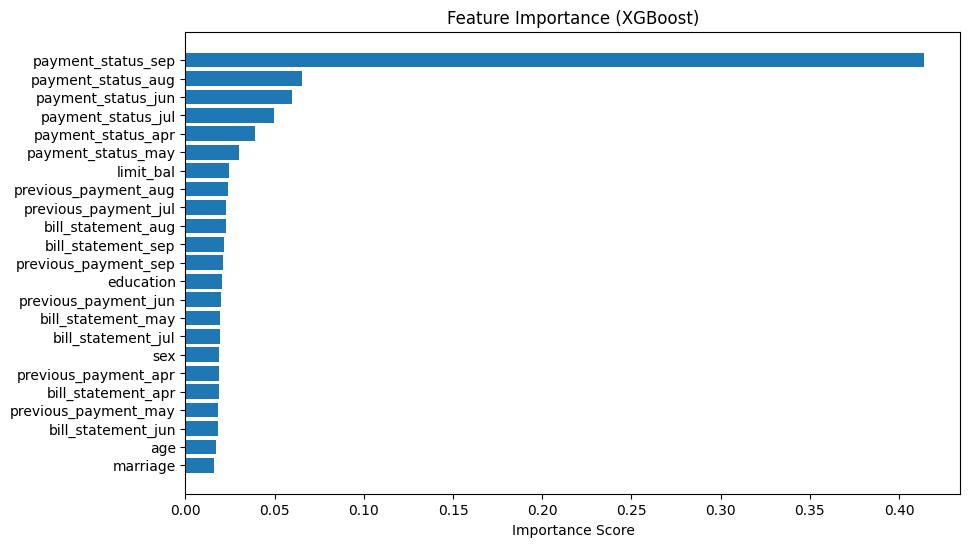

In [26]:
#feature importance
importances = xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(feature_importance_df["feature"], feature_importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

Feature importance analysis form the XGBoost model shows that payment history variables are the most significant predictors of credit default. In particular, recent payment status, especially for the most recent month, has the highest importance score by a large margin. In XGBoost, feature importance scores are derived from how often and how effectively a feature is used to split the data across all decision trees in the model. Specifically, the importance reflects the contribution of each feature to reducing prediction error, meaning featuresthat result in greater improvements in model accuracy receive higher scores. The results indicate that recent repayment behavior is the strongest indicator of future default risk. The importance of payment status decreases for older months, suggesting that more recent financial behavior carries greater predictive value. Financial variables such as credit limit and bill statements contribute moderately to the model, while demographic variables such as age, gender, and education have minimal impact. These findings suggest that credit default is primarily driven by behavioral patterns rather than demographic characteristics. 